In [1]:
import os
os.listdir('/content')

['.config', 'online+retail+ii.zip', 'sample_data']

In [2]:
import pandas as pd

df = pd.read_excel('/content/online_retail_II.xlsx')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/online_retail_II.xlsx'

In [3]:
import os

print(os.listdir('/content'))

['.config', 'online+retail+ii.zip', 'sample_data']


In [4]:
import zipfile
import os

zip_path = '/content/online+retail+ii.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/retail_data')

print("Files extracted successfully!")
print(os.listdir('/content/retail_data'))

Files extracted successfully!
['online_retail_II.xlsx']


In [5]:
import glob

files = glob.glob('/content/retail_data/**/*.xlsx',
                  recursive=True)

print(files)

['/content/retail_data/online_retail_II.xlsx']


In [6]:
import pandas as pd

df = pd.read_excel(files[0])

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
# Check column names
print("Columns:")
print(df.columns.tolist())

# Check dataset information
print("\nDataset information:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display first 5 rows
df.head()

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

Missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Coun

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
# Check the original dataset size
print("Before cleaning:", df.shape)

# Remove rows without Customer ID
df = df.dropna(subset=['Customer ID']).copy()

# Remove duplicate rows
df = df.drop_duplicates()

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Keep only valid purchase records
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print("After cleaning:", df.shape)
print("Missing Customer IDs:", df['Customer ID'].isnull().sum())

df.head()

Before cleaning: (525461, 8)
After cleaning: (400916, 8)
Missing Customer IDs: 0


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
# Extract the month of each transaction
df['InvoiceMonth'] = (
    df['InvoiceDate'].dt.to_period('M')
)

# Find each customer's first purchase month
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceMonth']
      .transform('min')
)

df[['Customer ID', 'InvoiceDate',
    'InvoiceMonth', 'CohortMonth']].head(10)

,Customer ID,InvoiceDate,InvoiceMonth,CohortMonth
0,13085.0,2009-12-01 07:45:00,2009-12,2009-12
1,13085.0,2009-12-01 07:45:00,2009-12,2009-12
2,13085.0,2009-12-01 07:45:00,2009-12,2009-12
3,13085.0,2009-12-01 07:45:00,2009-12,2009-12
4,13085.0,2009-12-01 07:45:00,2009-12,2009-12
5,13085.0,2009-12-01 07:45:00,2009-12,2009-12
6,13085.0,2009-12-01 07:45:00,2009-12,2009-12
7,13085.0,2009-12-01 07:45:00,2009-12,2009-12
8,13085.0,2009-12-01 07:46:00,2009-12,2009-12
9,13085.0,2009-12-01 07:46:00,2009-12,2009-12


In [10]:
# Extract the month of each transaction
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Find each customer's first purchase month
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceMonth']
      .transform('min')
)

# Display the results
df[['Customer ID', 'InvoiceDate',
    'InvoiceMonth', 'CohortMonth']].head(10)

,Customer ID,InvoiceDate,InvoiceMonth,CohortMonth
0,13085.0,2009-12-01 07:45:00,2009-12,2009-12
1,13085.0,2009-12-01 07:45:00,2009-12,2009-12
2,13085.0,2009-12-01 07:45:00,2009-12,2009-12
3,13085.0,2009-12-01 07:45:00,2009-12,2009-12
4,13085.0,2009-12-01 07:45:00,2009-12,2009-12
5,13085.0,2009-12-01 07:45:00,2009-12,2009-12
6,13085.0,2009-12-01 07:45:00,2009-12,2009-12
7,13085.0,2009-12-01 07:45:00,2009-12,2009-12
8,13085.0,2009-12-01 07:46:00,2009-12,2009-12
9,13085.0,2009-12-01 07:46:00,2009-12,2009-12


In [11]:
# Extract the month of each transaction
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Find each customer's first purchase month
df['CohortMonth'] = (
    df.groupby('Customer ID')['InvoiceMonth']
      .transform('min')
)

# Display the results
df[['Customer ID', 'InvoiceDate',
    'InvoiceMonth', 'CohortMonth']].head(10)

,Customer ID,InvoiceDate,InvoiceMonth,CohortMonth
0,13085.0,2009-12-01 07:45:00,2009-12,2009-12
1,13085.0,2009-12-01 07:45:00,2009-12,2009-12
2,13085.0,2009-12-01 07:45:00,2009-12,2009-12
3,13085.0,2009-12-01 07:45:00,2009-12,2009-12
4,13085.0,2009-12-01 07:45:00,2009-12,2009-12
5,13085.0,2009-12-01 07:45:00,2009-12,2009-12
6,13085.0,2009-12-01 07:45:00,2009-12,2009-12
7,13085.0,2009-12-01 07:45:00,2009-12,2009-12
8,13085.0,2009-12-01 07:46:00,2009-12,2009-12
9,13085.0,2009-12-01 07:46:00,2009-12,2009-12


In [12]:
# Calculate months since the first purchase
df['CohortIndex'] = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12
    + (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)
    + 1
)

df[['Customer ID', 'InvoiceMonth',
    'CohortMonth', 'CohortIndex']].head(10)

,Customer ID,InvoiceMonth,CohortMonth,CohortIndex
0,13085.0,2009-12,2009-12,1
1,13085.0,2009-12,2009-12,1
2,13085.0,2009-12,2009-12,1
3,13085.0,2009-12,2009-12,1
4,13085.0,2009-12,2009-12,1
5,13085.0,2009-12,2009-12,1
6,13085.0,2009-12,2009-12,1
7,13085.0,2009-12,2009-12,1
8,13085.0,2009-12,2009-12,1
9,13085.0,2009-12,2009-12,1


In [13]:
# Count unique customers in each cohort and month
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
      .nunique()
      .reset_index()
)

cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

cohort_counts.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN


In [14]:
# Get the number of customers in the first month
cohort_sizes = cohort_counts.iloc[:, 0]

# Calculate retention percentages
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

# Round to 2 decimal places
retention = retention.round(2)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,24.82
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,9.92,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,7.22,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,6.80,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,7.87,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,6.67,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,10.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,11.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


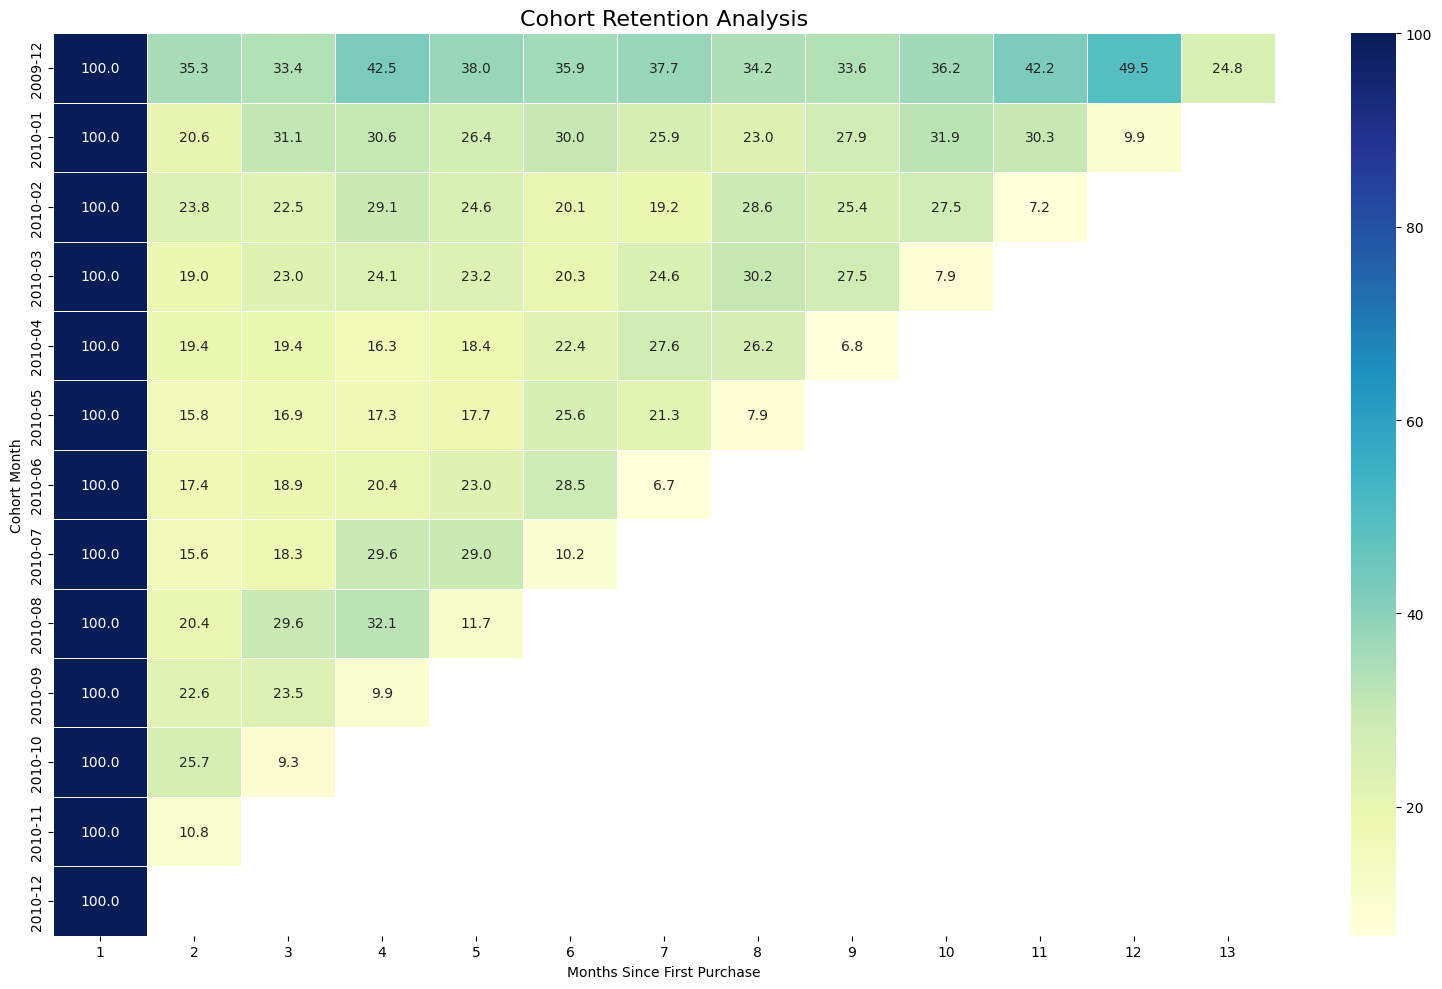

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Cohort Retention Analysis', fontsize=16)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

In [16]:
# Average retention by month
average_retention = retention.mean(axis=0).round(2)

print("Average Retention by Month:")
print(average_retention)

# Retention for the first and second months
print("\nFirst month retention:",
      average_retention.iloc[0], "%")

if len(average_retention) > 1:
    print("Second month retention:",
          average_retention.iloc[1], "%")

Average Retention by Month:
CohortIndex
1     100.00
2      20.53
3      22.35
4      25.19
5      23.56
6      24.14
7      23.27
8      25.02
9      24.26
10     25.88
11     26.57
12     29.72
13     24.82
dtype: float64

First month retention: 100.0 %
Second month retention: 20.53 %


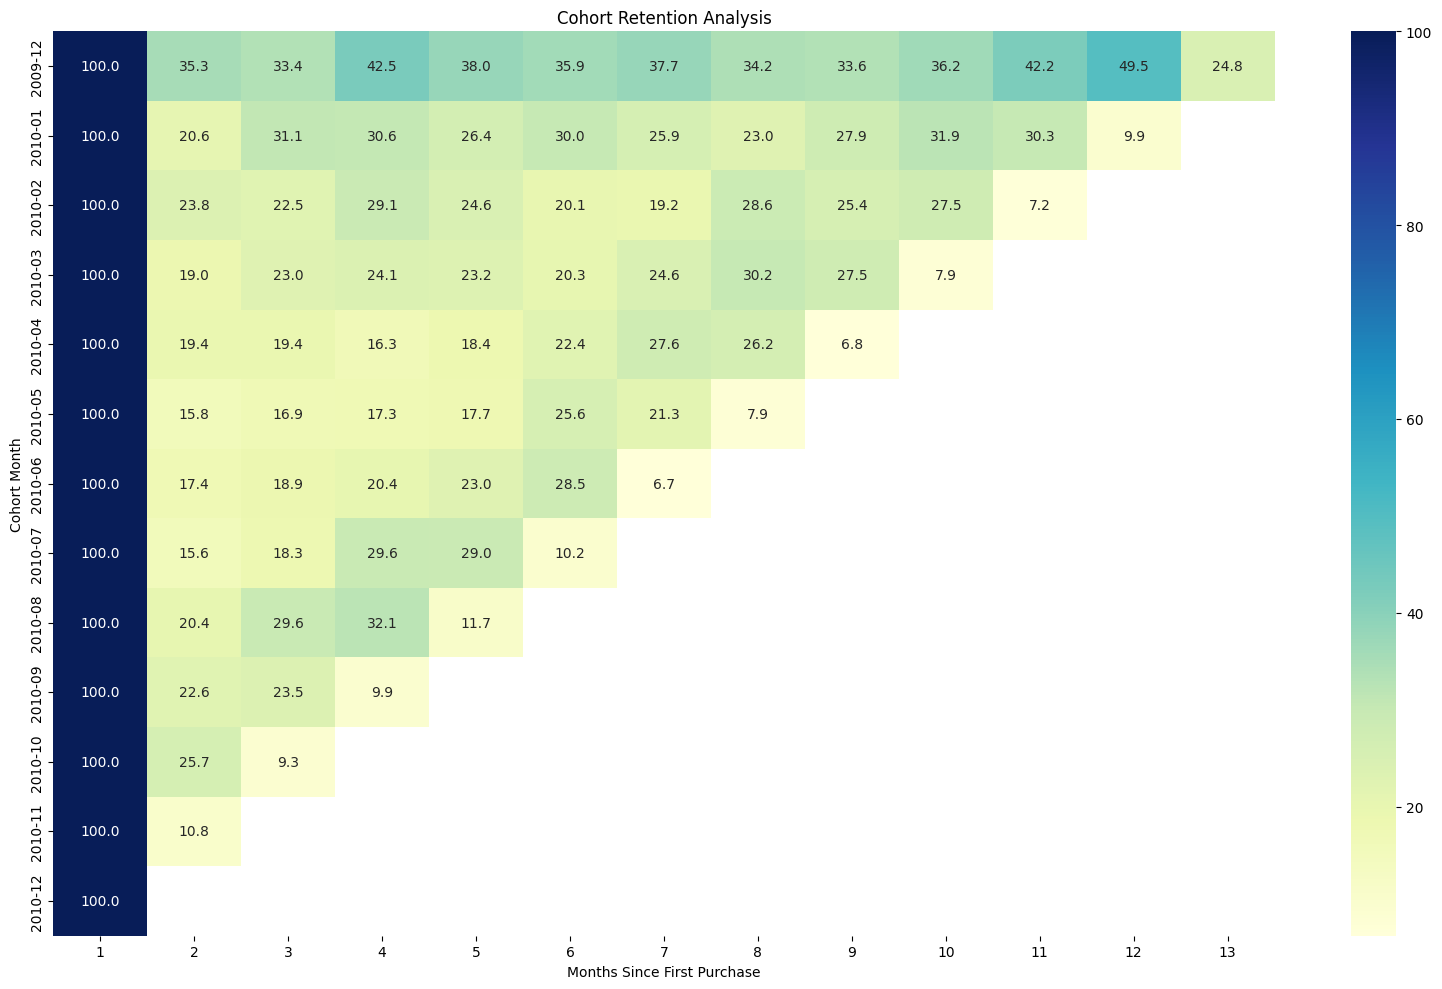

Files saved successfully!


In [17]:
# Save cohort tables
cohort_counts.to_csv('cohort_customer_counts.csv')
retention.to_csv('cohort_retention_percentages.csv')

# Save heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Cohort Retention Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=300)
plt.show()

print("Files saved successfully!")